In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from library import preprocess_smiles
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

In [6]:
DATA_SOURCE = "../data/AqSolDB/data_curated.csv"

In [7]:
df = pd.read_csv(DATA_SOURCE)

# preprocess the smiles for the quantumFP program
preprocessed_smiles = [preprocess_smiles(smiles) for smiles in df["SMILES"]]

print(len(preprocessed_smiles))

cleaned_smiles = []
solubilities = []
db_ids = []
for idx, smiles in enumerate(preprocessed_smiles):
    if smiles is not None:
        cleaned_smiles.append(smiles)
        db_ids.append(df.iloc[idx]["ID"])
        solubilities.append(df.iloc[idx]["Solubility"])

# Filter out all None instances returned from preprocess_smiles
# cleaned_smiles = list(filter(lambda x: x is not None, preprocessed_smiles))

[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:29] WARNING: not removing hydrogen atom without neighbors
[11:45:30] WARNING: not removing hydrogen atom without neighbors
[11:45:30] WARNING: not removing hydrogen atom without neighbors
[11:45:30] WARNING: not removing hydrogen atom without neighbors
[11:45:30] WARNING: not r

9982


KeyboardInterrupt: 

In [ ]:
feature_df = pd.DataFrame({"db_id": db_ids, "smiles": cleaned_smiles, "Solubility": solubilities})

# mols = [Chem.MolFromSmiles(smiles) for smiles in feature_df["smiles"]]
# feature_df['num_heavy_atoms'] = pd.DataFrame(
#     [mol.GetNumHeavyAtoms() for mol in mols]
# )

feature_df

,db_id,smiles,Solubility,num_heavy_atoms
0,A-4,[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c...,-3.254767,13
1,A-5,[Cl:1][c:2]1[c:3]([H:10])[c:4]([H:11])[c:5]([C...,-2.177078,9
2,A-9,[C:1]1([H:32])([H:33])[O:2][C:3]1([C:4]([N:5](...,-4.662065,31
3,A-10,[C:1]([c:2]1[c:3]([H:13])[c:4]([H:14])[c:5]([H...,-3.123150,9
4,A-11,[C:1]([C:2]([C:3]1([H:18])[C:4]([H:19])([H:20]...,-3.286116,12
...,...,...,...,...
8840,I-84,[C:1]([c:2]1[c:3]([H:20])[c:4]([H:21])[c:5]([N...,-3.010000,19
8841,I-85,[O:1]([c:2]1[c:3]2[c:29]([c:30]([H:54])[c:31](...,-2.930000,32
8842,I-86,[c:1]1([O:11][H:25])[c:2]([H:12])[c:3]([C:10](...,-2.190000,11
8843,I-93,[C:1]([O:2][c:3]1[c:4]([H:37])[c:5]([H:38])[c:...,-3.980000,33


In [ ]:
descriptor_names = [name for name, _ in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
len(descriptor_names)

217

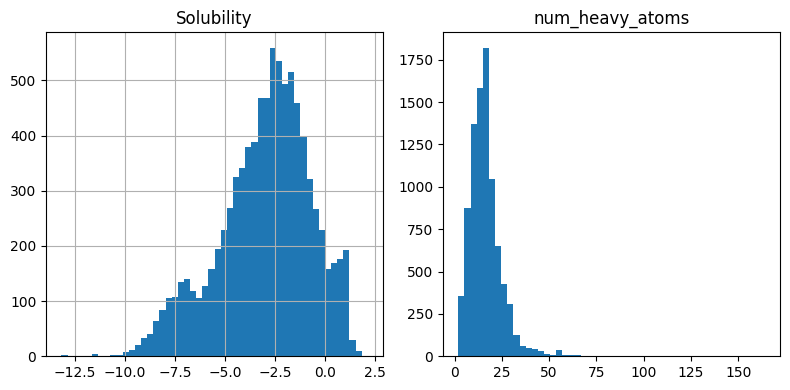

In [ ]:
subset_cols = ["Solubility", "num_heavy_atoms"]
subset_feature_df = feature_df[subset_cols]
subset_feature_df.hist(bins=50, figsize=(8, 4), layout=(1, len(subset_cols)))
plt.tight_layout()
plt.grid(False)
plt.show()